In [2]:
import wfdb
import matplotlib.pyplot as plt
import numpy as np
import torch.optim as optim

In [3]:
wfdb.dl_database('mitdb', dl_dir='../data', records=['100'])
record = wfdb.rdrecord('../data/100')
print(record)

Generating record list for: 100
Generating list of all files for: 100
Finished downloading files


In [4]:
print(record.sig_name)
print(record.fs)
print(record.p_signal.shape)

['MLII', 'V5']
360
(650000, 2)


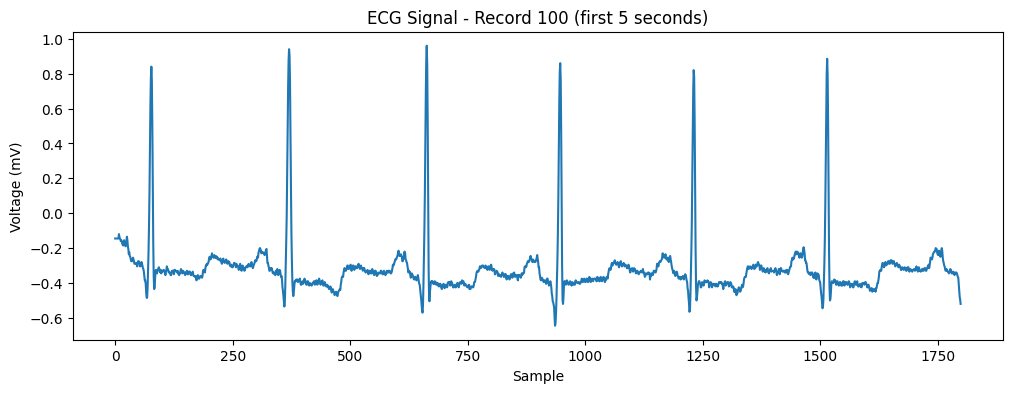

In [ ]:
    signal = record.p_signal[:, 0]
        
plt.figure(figsize=(12,4))
plt.plot(signal[0:1800])
plt.title('ECG Signal - Record 100 (first 5 seconds)')
plt.xlabel('Sample')
plt.ylabel('Voltage (mV)')
plt.show()


In [6]:
from scipy.signal import butter, filtfilt

def bandpass_filter(signal, lowcut=0.5, highcut=40.0, fs=360, order=4):
    nyq = fs/2
    low = lowcut /nyq
    high = highcut / nyq
    b, a = butter(order, [low,high], btype = 'band')
    return filtfilt(b, a, signal)


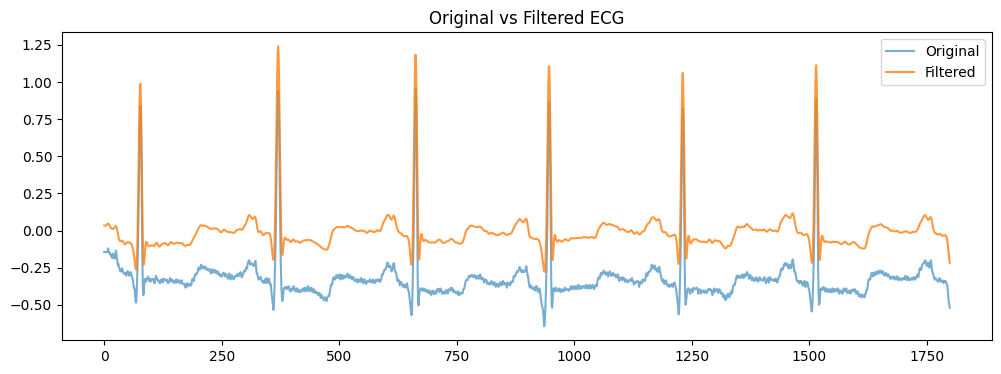

In [7]:
filtered_signal = bandpass_filter(signal)

plt.figure(figsize=(12, 4))
plt.plot(signal[0:1800], label='Original', alpha=0.6)
plt.plot(filtered_signal[0:1800], label = 'Filtered', alpha=0.8)
plt.legend()
plt.title('Original vs Filtered ECG')
plt.show()

In [8]:
import wfdb.processing

peaks = wfdb.processing.gqrs_detect(filtered_signal, fs=360)
print(f"Found {len(peaks)} heartbeats")
print(f"First 10 peak locations: {peaks[:10]}")

Found 2272 heartbeats
First 10 peak locations: [ 357  650  934 1218 1502 1797 2032 2390 2693 2985]


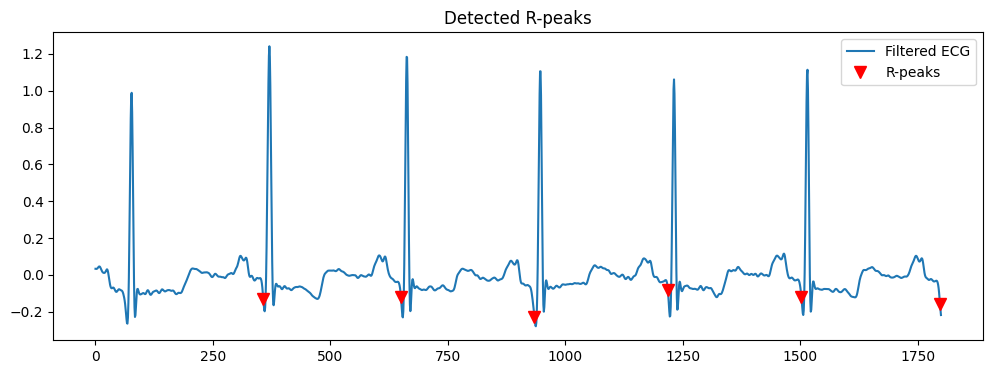

In [9]:
plt.figure(figsize=(12, 4))
plt.plot(filtered_signal[0:1800], label='Filtered ECG')
plt.plot(peaks[peaks< 1800], filtered_signal[peaks[peaks <1800]], 'rv', markersize=8, label='R-peaks')
plt.legend()
plt.title('Detected R-peaks')
plt.show()

In [10]:
window = 180

beats = []
for peak in peaks:
    if peak - window >= 0 and peak + window <= len(filtered_signal):
        beat = filtered_signal[peak - window : peak + window]
        beats.append(beat)

beats = np.array(beats)
print(beats.shape)

(2271, 360)


In [11]:
def normalized_beat(beat):
    mean = np.mean(beat)
    std = np.std(beat)
    return (beat - mean) / std
normalized_beats = np.array([normalized_beat(beat) for beat in beats])
print(normalized_beats.shape)

(2271, 360)


In [12]:
annotation = wfdb.rdann('../data/100', 'atr')
print(annotation.symbol[:20])
print(annotation.sample[:20])

['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N']
[  18   77  370  662  946 1231 1515 1809 2044 2402 2706 2998 3282 3560
 3862 4170 4466 4764 5060 5346]


In [13]:
print(np.unique(annotation.symbol, return_counts=True))

(array(['+', 'A', 'N', 'V'], dtype='<U1'), array([   1,   33, 2239,    1]))


In [14]:
label_map = {'N': 0, 'L': 0, 'R':0, 'e':0, 'j':0,
             'A': 1, 'a': 1, 'J': 1, 'S':1,
             'V': 2, 'E':2,
             'F': 3,
             '/':4, 'f': 4, 'Q': 4}
labels = []
for peak in peaks:
    diff = np.abs(annotation.sample - peak)
    closest = np.argmin(diff)
    symbol = annotation.symbol[closest]
    if symbol in label_map:
        labels.append(label_map[symbol])
 

labels = np.array(labels)
print(f"Total labels: {len(labels)}")
print(np.unique(labels, return_counts=True))

Total labels: 2272
(array([0, 1, 2]), array([2238,   33,    1]))


In [15]:
import torch
import torch.nn as nn

class ECGClassifier(nn.Module):
    def __init__(self):
        super(ECGClassifier, self).__init__()
        self.conv1 = nn.Conv1d(1, 32, kernel_size=5, padding=2)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.pool = nn.MaxPool1d(2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(128 * 45, 256)
        self.fc2 = nn.Linear(256, 5)
    
    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(self.relu(self.fc1(x)))
        return self.fc2(x)

In [16]:
model = ECGClassifier()
print(model)

ECGClassifier(
  (conv1): Conv1d(1, 32, kernel_size=(5,), stride=(1,), padding=(2,))
  (conv2): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
  (conv3): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=5760, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=5, bias=True)
)


In [17]:
labels = labels[:len(normalized_beats)]
print(len(normalized_beats), len(labels))

2271 2271


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    normalized_beats, labels, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

Training samples: 1816
Test samples: 455


In [19]:
X_train_t = torch.FloatTensor(X_train).squeeze().unsqueeze(1)
X_test_t = torch.FloatTensor(X_test).squeeze().unsqueeze(1)
y_train_t = torch.LongTensor(y_train)
y_test_t = torch.LongTensor(y_test)

print(X_train_t.shape)
print(X_test_t.shape)

torch.Size([1816, 1, 360])
torch.Size([455, 1, 360])


In [20]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

print(f"Training batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Training batches: 57
Test batches: 15


In [21]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [22]:
epochs = 30

for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct = 0

    for beats, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(beats)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        predicted = outputs.argmax(1)
        correct += (predicted == labels).sum().item()

acc = correct / len(X_train) * 100
print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss:.4f} - Accuracy: {acc:.2f}%")

Epoch 30/30 - Loss: 0.0012 - Accuracy: 100.00%


In [23]:
model.eval()
correct = 0
all_predicted = []
all_labels = []

with torch.no_grad():
    for beats, labels in test_loader:
        outputs = model(beats)
        predicted = outputs.argmax(1)
        correct += (predicted == labels).sum().item()
        all_predicted.extend(predicted.numpy())
        all_labels.extend(labels.numpy())

test_acc = correct / len(X_test) * 100
print(f"Test Accuracy: {test_acc:.2f}%")

Test Accuracy: 100.00%


In [24]:
import numpy as np
print(np.unique(all_predicted, return_counts=True))

(array([0, 1]), array([448,   7]))


In [25]:
from sklearn.metrics import confusion_matrix, classification_report
print(classification_report(all_labels, all_predicted))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       448
           1       1.00      1.00      1.00         7

    accuracy                           1.00       455
   macro avg       1.00      1.00      1.00       455
weighted avg       1.00      1.00      1.00       455



In [26]:
all_records = [
    '100','101','102','103','104','105','106','107',
    '108','109','111','112','113','114','115','116',
    '117','118','119','121','122','123','124','200',
    '201','202','203','205','207','208','209','210',
    '212','213','214','215','217','219','220','221',
    '222','223','228','230','231','232','233','234'
]
print(len(all_records))

48


In [27]:
all_beats = []
all_labels = []

for rec in all_records:
    try:
        wfdb.dl_database('mitdb', dl_dir='../data', records=[rec])
        record = wfdb.rdrecord(f'../data/{rec}')
        annotation = wfdb.rdann(f'../data/{rec}', 'atr')

        signal = record.p_signal[:, 0]
        filtered = bandpass_filter(signal)
        peaks = wfdb.processing.gqrs_detect(filtered, fs=360)

        for peak in peaks:
            if peak - 180 >= 0 and peak + 180 <= len(filtered):
                beat = filtered[peak - 180 : peak + 180]
                beat = normalized_beat(beat)
                diff = np.abs(annotation.sample - peak)
                closest = np.argmin(diff)
                symbol = annotation.symbol[closest]
                if symbol in label_map:
                    all_beats.append(beat)
                    all_labels.append(label_map[symbol])
    except:
        print(f"skipping record {rec}")

all_beats = np.array(all_beats)
all_labels = np.array(all_labels)
print(all_beats.shape)
print(np.unique(all_labels, return_counts=True))

Generating record list for: 100
Generating list of all files for: 100
Finished downloading files
Generating record list for: 101
Generating list of all files for: 101
Finished downloading files
Generating record list for: 102
Generating list of all files for: 102
Finished downloading files
Generating record list for: 103
Generating list of all files for: 103
Finished downloading files
Generating record list for: 104
Generating list of all files for: 104
Finished downloading files
Generating record list for: 105
Generating list of all files for: 105
Finished downloading files
Generating record list for: 106
Generating list of all files for: 106
Finished downloading files
Generating record list for: 107
Generating list of all files for: 107
Finished downloading files
Generating record list for: 108
Generating list of all files for: 108
Finished downloading files
Generating record list for: 109
Generating list of all files for: 109
Finished downloading files
Generating record list for: 11

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_rest, y_train, y_test = train_test_split(
all_beats, all_labels, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

Training samples: 87802
Test samples: 455


In [29]:
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Total: {len(X_train) + len(X_test)}")

Training samples: 87802
Test samples: 455
Total: 88257


In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    all_beats, all_labels, test_size=0.2, random_state=42)

print(f"Training: {len(X_train)}")
print(f"Test: {len(X_test)}")
print(f"Total: {len(X_train) + len(X_test)}")

Training: 87802
Test: 21951
Total: 109753


In [31]:
X_train_t = torch.FloatTensor(X_train).unsqueeze(1)
X_test_t = torch.FloatTensor(X_test).unsqueeze(1)
y_train_t = torch.LongTensor(y_train)
y_test_t = torch.LongTensor(y_test)

train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

print(f"Training batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Training batches: 2744
Test batches: 686


In [43]:
model = ECGClassifier()
class_counts = np.bincount(y_train)
class_weights = 1.0 / class_counts
weights = torch.FloatTensor(class_weights)
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 30

for epoch in range(epochs): 
    model.train()
    total_loss = 0
    correct = 0

    for beats, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(beats)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        predicted = outputs.argmax(1)
        correct += (predicted == labels).sum().item()

    acc = correct / len(X_train) * 100
    print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss:.4f} - Accuracy: {acc:.2f} %")

Epoch 1/30 - Loss: 957.6520 - Accuracy: 88.72 %
Epoch 2/30 - Loss: 497.1172 - Accuracy: 93.81 %
Epoch 3/30 - Loss: 411.9739 - Accuracy: 94.71 %
Epoch 4/30 - Loss: 325.8620 - Accuracy: 95.71 %
Epoch 5/30 - Loss: 303.3682 - Accuracy: 96.13 %
Epoch 6/30 - Loss: 257.6036 - Accuracy: 96.73 %
Epoch 7/30 - Loss: 266.5290 - Accuracy: 96.80 %
Epoch 8/30 - Loss: 228.5428 - Accuracy: 96.94 %
Epoch 9/30 - Loss: 242.3646 - Accuracy: 97.09 %
Epoch 10/30 - Loss: 228.9536 - Accuracy: 97.15 %
Epoch 11/30 - Loss: 201.6376 - Accuracy: 97.39 %
Epoch 12/30 - Loss: 191.2799 - Accuracy: 97.40 %
Epoch 13/30 - Loss: 181.3371 - Accuracy: 97.65 %
Epoch 14/30 - Loss: 192.0721 - Accuracy: 97.71 %
Epoch 15/30 - Loss: 174.1449 - Accuracy: 97.80 %
Epoch 16/30 - Loss: 206.0050 - Accuracy: 97.43 %
Epoch 17/30 - Loss: 178.9009 - Accuracy: 97.84 %
Epoch 18/30 - Loss: 190.7540 - Accuracy: 97.76 %
Epoch 19/30 - Loss: 177.2490 - Accuracy: 97.81 %
Epoch 20/30 - Loss: 211.6817 - Accuracy: 97.51 %
Epoch 21/30 - Loss: 154.7370 

In [44]:
model.eval()
correct = 0
all_predicted = []
all_labels_test = []

with torch.no_grad():
    for beats, labels in test_loader:
        outputs = model(beats)
        predicted = outputs.argmax(1)
        correct += (predicted == labels).sum().item()
        all_predicted.extend(predicted.numpy())
        all_labels_test.extend(labels.numpy())

test_acc = correct / len(X_test) * 100
print(f"Test Accuracy: {test_acc:2f}%")
print(classification_report(all_labels_test, all_predicted))

Test Accuracy: 98.300761%
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     18142
           1       0.83      0.91      0.87       547
           2       0.94      0.97      0.96      1481
           3       0.65      0.91      0.75       149
           4       0.98      0.99      0.98      1632

    accuracy                           0.98     21951
   macro avg       0.88      0.95      0.91     21951
weighted avg       0.98      0.98      0.98     21951



In [2]:
torch.save(model.state_dict(), '../results/ecg_model.pth')
np.save('../data/all_beats.npy', all_beats)
np.save('../data/all_labels.npy', all_labels)
print("Model and data saved!")

NameError: name 'model' is not defined

In [16]:
import torch
import torch.nn as nn
import torch.onnx

class ECGClassifier(nn.Module):
    def __init__(self):
        super(ECGClassifier, self).__init__()
        self.conv1 = nn.Conv1d(1, 32, kernel_size=5, padding=2)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.pool = nn.MaxPool1d(2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(128 * 45, 256)
        self.fc2 = nn.Linear(256, 5)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(self.relu(self.fc1(x)))
        return self.fc2(x)

model_export = ECGClassifier()
model_export.load_state_dict(torch.load('../results/ecg_model.pth', map_location='cpu'))
model_export.eval()

dummy_input = torch.randn(1, 1, 360)

torch.onnx.export(
    model_export,
    dummy_input,
    '../results/ecg_model.onnx',
    export_params=True,
    opset_version=11,
    dynamo=False,               # use legacy exporter — no onnxscript needed
    input_names=['ecg_input'],
    output_names=['class_scores'],
    dynamic_axes={
        'ecg_input':    {0: 'batch_size'},
        'class_scores': {0: 'batch_size'}
    }
)

print("Exported: results/ecg_model.onnx")

Exported: results/ecg_model.onnx


C:\Users\Jgaho\AppData\Local\Temp\ipykernel_37468\847387713.py:31: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


In [15]:
import onnx
import os

onnx_model = onnx.load('../results/ecg_model.onnx')
onnx.checker.check_model(onnx_model)

size_kb = os.path.getsize('../results/ecg_model.onnx') / 1024
print(f"Model valid: True")
print(f"File size:   {size_kb:.1f} 1KB")
print(f"Input:       {onnx_model.graph.input[0].name}  shape: 1 x 1 x 360")
print(f"Output:      {onnx_model.graph.output[0].name} shape: 1 x 5")
print()
print("Ready to load into STM32CubeAI.")

Model valid: True
File size:   5969.9 1KB
Input:       ecg_input  shape: 1 x 1 x 360
Output:      class_scores shape: 1 x 5

Ready to load into STM32CubeAI.


In [17]:
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

all_beats  = np.load('../data/all_beats.npy')
all_labels = np.load('../data/all_labels.npy')

print(f"Beats: {all_beats.shape}")
print(f"Class distribution: {np.unique(all_labels, return_counts=True)}")

X_train, X_test, y_train, y_test = train_test_split(
    all_beats, all_labels, test_size=0.2, random_state=42)

X_train_t = torch.FloatTensor(X_train).unsqueeze(1)
X_test_t  = torch.FloatTensor(X_test).unsqueeze(1)
y_train_t = torch.LongTensor(y_train)
y_test_t  = torch.LongTensor(y_test)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_t,  y_test_t),  batch_size=32)

print(f"Train: {len(X_train)}  Test: {len(X_test)}")

Beats: (109753, 360)
Class distribution: (array([0, 1, 2, 3, 4]), array([90869,  2790,  7236,   799,  8059]))
Train: 87802  Test: 21951


In [18]:
import torch.nn as nn
import torch.optim as optim

class ECGClassifierV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv1d(1,   32,  kernel_size=5, padding=2)
        self.conv2 = nn.Conv1d(32,  64,  kernel_size=5, padding=2)
        self.conv3 = nn.Conv1d(64,  128, kernel_size=5, padding=2)
        self.pool       = nn.MaxPool1d(2)
        self.pool_adapt = nn.AvgPool1d(kernel_size=11, stride=11)  # 45 → 4 outputs, ONNX-safe
        self.relu       = nn.ReLU()
        self.dropout    = nn.Dropout(0.5)
        self.fc1 = nn.Linear(512, 128)   # 128 ch × 4 = 512
        self.fc2 = nn.Linear(128, 5)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = self.pool_adapt(x)            # (batch, 128, 45) → (batch, 128, 4)
        x = x.view(x.size(0), -1)        # → (batch, 512)
        x = self.dropout(self.relu(self.fc1(x)))
        return self.fc2(x)

model_v2 = ECGClassifierV2()
total_params = sum(p.numel() for p in model_v2.parameters())
print(f"Parameters: {total_params:,}  (~{total_params*4/1024:.0f} KB float32, ~{total_params/1024:.0f} KB INT8)")

class_counts  = np.bincount(y_train)
class_weights = torch.FloatTensor(1.0 / class_counts)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model_v2.parameters(), lr=0.001)

epochs = 30
for epoch in range(epochs):
    model_v2.train()
    total_loss = 0
    correct    = 0
    for beats, labels in train_loader:
        optimizer.zero_grad()
        outputs = model_v2(beats)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += (outputs.argmax(1) == labels).sum().item()
    acc = correct / len(X_train) * 100
    print(f"Epoch {epoch+1:2d}/{epochs} - Loss: {total_loss:.4f} - Acc: {acc:.2f}%")

Parameters: 117,893  (~461 KB float32, ~115 KB INT8)
Epoch  1/30 - Loss: 1449.5025 - Acc: 81.61%
Epoch  2/30 - Loss: 851.9783 - Acc: 89.18%
Epoch  3/30 - Loss: 681.4500 - Acc: 91.34%
Epoch  4/30 - Loss: 610.9188 - Acc: 92.31%
Epoch  5/30 - Loss: 538.9085 - Acc: 92.84%
Epoch  6/30 - Loss: 465.9614 - Acc: 93.42%
Epoch  7/30 - Loss: 454.0670 - Acc: 93.30%
Epoch  8/30 - Loss: 427.3729 - Acc: 94.01%
Epoch  9/30 - Loss: 383.4053 - Acc: 94.38%
Epoch 10/30 - Loss: 366.5894 - Acc: 94.78%
Epoch 11/30 - Loss: 369.0892 - Acc: 94.73%
Epoch 12/30 - Loss: 345.6174 - Acc: 94.76%
Epoch 13/30 - Loss: 354.1625 - Acc: 94.69%
Epoch 14/30 - Loss: 320.5927 - Acc: 94.86%
Epoch 15/30 - Loss: 312.5796 - Acc: 95.16%
Epoch 16/30 - Loss: 294.7468 - Acc: 95.40%
Epoch 17/30 - Loss: 302.9707 - Acc: 95.15%
Epoch 18/30 - Loss: 288.0310 - Acc: 95.64%
Epoch 19/30 - Loss: 287.7721 - Acc: 95.45%
Epoch 20/30 - Loss: 286.1020 - Acc: 95.51%
Epoch 21/30 - Loss: 260.2199 - Acc: 95.56%
Epoch 22/30 - Loss: 292.2848 - Acc: 95.40%


In [19]:
from sklearn.metrics import classification_report
import torch.onnx
import os

model_v2.eval()
all_pred_v2   = []
all_labels_v2 = []
correct = 0

with torch.no_grad():
    for beats, labels in test_loader:
        outputs   = model_v2(beats)
        predicted = outputs.argmax(1)
        correct  += (predicted == labels).sum().item()
        all_pred_v2.extend(predicted.numpy())
        all_labels_v2.extend(labels.numpy())

print(f"Test Accuracy: {correct / len(X_test) * 100:.2f}%")
print(classification_report(all_labels_v2, all_pred_v2,
      target_names=['N', 'S', 'V', 'F', 'Q']))

torch.save(model_v2.state_dict(), '../results/ecg_model_v2.pth')

dummy_input = torch.randn(1, 1, 360)
torch.onnx.export(
    model_v2, dummy_input, '../results/ecg_model_v2.onnx',
    export_params=True, opset_version=11, dynamo=False,
    input_names=['ecg_input'], output_names=['class_scores'],
    dynamic_axes={'ecg_input': {0: 'batch_size'}, 'class_scores': {0: 'batch_size'}}
)

size_kb = os.path.getsize('../results/ecg_model_v2.onnx') / 1024
print(f"\nONNX size: {size_kb:.1f} KB  (was 5969.9 KB)")
print("Done. Load ecg_model_v2.onnx into STM32CubeAI.")

Test Accuracy: 98.14%
              precision    recall  f1-score   support

           N       0.99      0.98      0.99     18142
           S       0.73      0.90      0.81       547
           V       0.97      0.97      0.97      1481
           F       0.75      0.87      0.80       149
           Q       0.97      0.99      0.98      1632

    accuracy                           0.98     21951
   macro avg       0.88      0.94      0.91     21951
weighted avg       0.98      0.98      0.98     21951


ONNX size: 463.1 KB  (was 5969.9 KB)
Done. Load ecg_model_v2.onnx into STM32CubeAI.


C:\Users\Jgaho\AppData\Local\Temp\ipykernel_37468\1270074055.py:25: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


In [ ]:
import torch.nn as nn
import torch.optim as optim

class ECGClassifierV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv1d(1,   32,  kernel_size=5, padding=2)
        self.conv2 = nn.Conv1d(32,  64,  kernel_size=5, padding=2)
        self.conv3 = nn.Conv1d(64,  128, kernel_size=5, padding=2)
        self.pool    = nn.MaxPool1d(2)
        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(128, 64)
        self.fc2 = nn.Linear(64, 5)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = x.mean(dim=2)              # Global Average Pooling
        x = self.dropout(self.relu(self.fc1(x)))
        return self.fc2(x)

model_v2 = ECGClassifierV2()
total_params = sum(p.numel() for p in model_v2.parameters())
print(f"Parameters: {total_params:,}  (~{total_params*4/1024:.0f} KB float32, ~{total_params/1024:.0f} KB INT8)")

class_counts  = np.bincount(y_train)
class_weights = torch.FloatTensor(1.0 / class_counts)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model_v2.parameters(), lr=0.001)

epochs = 30
for epoch in range(epochs):
    model_v2.train()
    total_loss = 0
    correct    = 0
    for beats, labels in train_loader:
        optimizer.zero_grad()
        outputs = model_v2(beats)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += (outputs.argmax(1) == labels).sum().item()
    acc = correct / len(X_train) * 100
    print(f"Epoch {epoch+1:2d}/{epochs} - Loss: {total_loss:.4f} - Acc: {acc:.2f}%")

Parameters: 60,165  (~235 KB float32, ~59 KB INT8)
Epoch  1/30 - Loss: 2272.4173 - Acc: 68.52%
Epoch  2/30 - Loss: 1295.8870 - Acc: 81.32%
Epoch  3/30 - Loss: 1075.0567 - Acc: 85.11%
Epoch  4/30 - Loss: 967.4262 - Acc: 86.97%
Epoch  5/30 - Loss: 857.3064 - Acc: 88.87%
Epoch  6/30 - Loss: 767.3996 - Acc: 89.84%
Epoch  7/30 - Loss: 731.0122 - Acc: 90.09%
Epoch  8/30 - Loss: 695.0031 - Acc: 91.06%
Epoch  9/30 - Loss: 630.8692 - Acc: 91.30%
Epoch 10/30 - Loss: 640.7778 - Acc: 91.60%
Epoch 11/30 - Loss: 582.3277 - Acc: 92.40%
Epoch 12/30 - Loss: 572.1982 - Acc: 92.18%
Epoch 13/30 - Loss: 528.9490 - Acc: 92.56%
Epoch 14/30 - Loss: 525.9291 - Acc: 92.95%
Epoch 15/30 - Loss: 502.3621 - Acc: 92.75%
Epoch 16/30 - Loss: 463.7702 - Acc: 92.81%
Epoch 17/30 - Loss: 472.1287 - Acc: 93.14%
Epoch 18/30 - Loss: 454.4974 - Acc: 93.36%
Epoch 19/30 - Loss: 447.4261 - Acc: 93.32%
Epoch 20/30 - Loss: 431.3627 - Acc: 93.29%
Epoch 21/30 - Loss: 422.7104 - Acc: 93.23%
Epoch 22/30 - Loss: 425.2468 - Acc: 93.19%


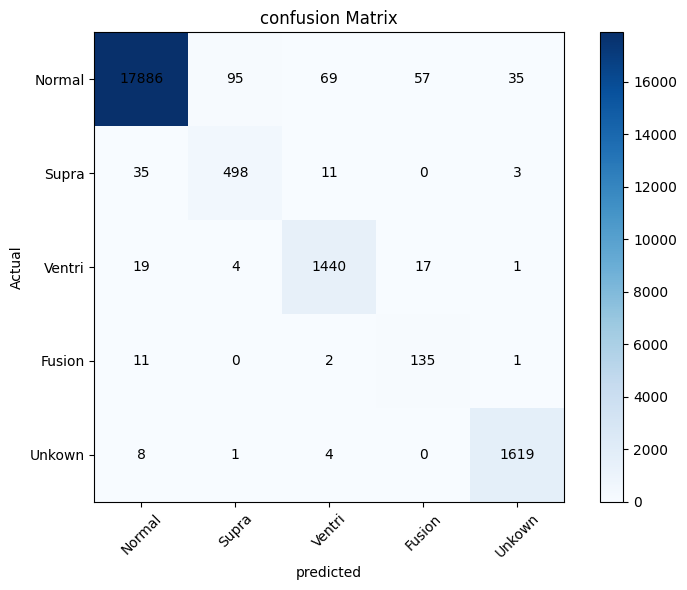

In [46]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(all_labels_test, all_predicted)
class_names = ['Normal', 'Supra', 'Ventri', 'Fusion', 'Unkown']

plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xticks(range(5), class_names, rotation=45)
plt.yticks(range(5),class_names)
plt.xlabel('predicted')
plt.ylabel('Actual')
plt.title('confusion Matrix')

for i in range(5):
    for j in range(5):
        plt.text(j, i, cm[i,j], ha='center', va='center')

plt.tight_layout()
plt.savefig('../results/confusion_matrix.png')
plt.show()

In [47]:
print(f"Test Accuracy: {test_acc:.2f}%")
print(classification_report(all_labels_test, all_predicted))

Test Accuracy: 98.30%
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     18142
           1       0.83      0.91      0.87       547
           2       0.94      0.97      0.96      1481
           3       0.65      0.91      0.75       149
           4       0.98      0.99      0.98      1632

    accuracy                           0.98     21951
   macro avg       0.88      0.95      0.91     21951
weighted avg       0.98      0.98      0.98     21951

